# Cas Kaggle - Predicció obessitat
https://www.kaggle.com/datasets/aravindpcoder/obesity-or-cvd-risk-classifyregressorcluster/data

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
import time

from sklearn.linear_model import LogisticRegression, LinearRegression
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Lasso, Ridge
from sklearn.tree import  DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,\
make_scorer,accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report



### Descripció de les variables
- Frequent consumption of high caloric food (FAVC)
- Frequency of consumption of vegetables (FCVC) 
- Number of main meals (NCP)
- Consumption of food between meals (CAEC)
- Consumption of water daily (CH20)
- Consumption of alcohol (CALC). 
- Calories consumption monitoring (SCC)
- Physical activity frequency (FAF)
- Time using technology devices (TUE)
- Transportation used (MTRANS)

## Dividir training i test

In [116]:
# Carregar el CSV en un DataFrame
df_full = pd.read_csv("ObesityDataSet.csv", encoding="utf-8")

# Mostrar les primeres files
df_full



,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


Dividim el dataset per 80(train + cv) - 20 test

In [117]:
# Dividir les dades en train i test
X = df_full[[col for col in df_full.columns if col != 'NObeyesdad']]
y = df_full['NObeyesdad']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1688, 16), (423, 16), (1688,), (423,))

## Explortory data analysis

In [118]:
# Crear un DataFrame que utilitzarem per entrenar i validar els models
df_split = pd.concat([X_train, y_train], axis=1)
# Crear un DataFrame que utilitzarem al final per provar el model triat
df_tester = pd.concat([X_test, y_test], axis=1)

# mostrem el conjunt d'entrenament i validació 
df_split


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
459,Male,19.000000,1.760000,79.000000,yes,yes,2.000000,3.000000,Frequently,no,3.000000,no,1.000000,2.000000,Frequently,Public_Transportation,Overweight_Level_I
426,Male,22.000000,1.750000,70.000000,no,no,2.000000,3.000000,Sometimes,no,3.000000,no,1.000000,1.000000,no,Public_Transportation,Normal_Weight
326,Male,18.000000,1.700000,55.300000,yes,yes,3.000000,3.000000,Sometimes,no,2.000000,no,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
971,Male,19.506389,1.824449,87.656029,yes,yes,2.793561,3.788602,Sometimes,no,2.429059,no,2.094542,0.393358,Sometimes,Public_Transportation,Overweight_Level_I
892,Female,17.085250,1.535618,57.259124,no,yes,1.972545,2.339614,Sometimes,no,1.711074,yes,0.095517,1.191053,Sometimes,Public_Transportation,Overweight_Level_I
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,Female,25.000000,1.630000,93.000000,no,no,3.000000,4.000000,Always,no,1.000000,no,2.000000,0.000000,no,Public_Transportation,Obesity_Type_II
1439,Female,40.654155,1.529060,79.760922,yes,yes,2.000000,3.000000,Sometimes,no,1.000000,no,0.000000,0.000000,Sometimes,Automobile,Obesity_Type_I
609,Male,19.979810,1.753360,54.997374,yes,yes,2.000000,3.494849,Sometimes,no,2.976672,no,1.949070,2.000000,no,Public_Transportation,Insufficient_Weight
1589,Male,38.523646,1.765836,118.533246,yes,yes,2.177896,2.987652,Sometimes,no,1.745095,no,0.656548,0.000000,Sometimes,Automobile,Obesity_Type_II


In [119]:
print(df_split.describe())

               Age       Height       Weight         FCVC          NCP  \
count  1688.000000  1688.000000  1688.000000  1688.000000  1688.000000   
mean     24.310222     1.701758    86.549808     2.428400     2.688133   
std       6.392643     0.093884    26.053319     0.529317     0.775336   
min      15.000000     1.456346    39.000000     1.000000     1.000000   
25%      19.918283     1.628799    65.137137     2.000000     2.663260   
50%      22.725431     1.701392    83.319978     2.414600     3.000000   
75%      26.000000     1.770000   107.046109     3.000000     3.000000   
max      61.000000     1.980000   160.639405     3.000000     4.000000   

              CH2O          FAF          TUE  
count  1688.000000  1688.000000  1688.000000  
mean      2.017965     1.020554     0.653900  
std       0.613215     0.847575     0.600574  
min       1.000000     0.000000     0.000000  
25%       1.622384     0.132315     0.000000  
50%       2.000000     1.000000     0.619850  
75% 

In [120]:
print("Número d'atributs del dataset:", len(df_split.keys()))
print("Número de files en el train (mostres): ",df_split.shape[0])

Número d'atributs del dataset: 17
Número de files en el train (mostres):  1688


In [121]:
# Mirem valors NaN per atribut
nan_counts = df_tester.isna().sum()
var_type = df_split.dtypes
# Mostrem una taula amb els valors NaN i el tipus de variable
print("Valors NaN per atribut i tipus de variable:")
print(pd.DataFrame({"NaN Count": nan_counts, "Variable Type": var_type}))

Valors NaN per atribut i tipus de variable:
                                NaN Count Variable Type
Gender                                  0        object
Age                                     0       float64
Height                                  0       float64
Weight                                  0       float64
family_history_with_overweight          0        object
FAVC                                    0        object
FCVC                                    0       float64
NCP                                     0       float64
CAEC                                    0        object
SMOKE                                   0        object
CH2O                                    0       float64
SCC                                     0        object
FAF                                     0       float64
TUE                                     0       float64
CALC                                    0        object
MTRANS                                  0        object
NObe

Veiem que cap atribut té valors NaN per tant no haurem de fer cap nateja. Per altra banda, veiem que tenim dos tipus de variables:

Variables catagòriques:
- GENDER (dona/home): binària
- family_history_with_overweight (si/no): binària
- Consum freqüent d'aliments en calories - FAVC (si/no):binària
- Menjar entre àpats - CAEC (sempre, freqüent, a vegades, no): ordinal
- Fumar - SMOKE (sí/no): binària
- Monitorització del consum de calories - SCC (sí/no): binària
- Consum d'alcohol - CALC (sempre, freqüent, a vegades, no): ordinal
- Mitjà de transport - MTRANS (automobil, moto, trans public, caminar, bici): categòrica
- Tipus d'obestitat (obesitat tipus 1/2, sobrepres 1/2, pes normal, pes insuficient): Sorgeix el dubte de si és ordinal o categòrica. Pel cas de classificació considerem que és categòrica.

Variables númeriques:
- Edat - AGE
- Alçada - HEIGHT
- Pes - WEIGHT
- Frequencia del consum de verdures - FCVC
- Número d'àpats al dia - NCP
- Consum d'aigua - CH20
- Freq d'activitat física - FAF
- Temps d'ús de dispositius tecnològics - TUE


C:\Users\annit\AppData\Local\Temp\ipykernel_26592\3921934752.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\annit\AppData\Local\Temp\ipykernel_26592\3921934752.py:13: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.countplot(
C:\Users\annit\AppData\Local\Temp\ipykernel_26592\3921934752.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
C:\Users\annit\AppData\Local\Temp\ipykernel_26592\3921934752.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\

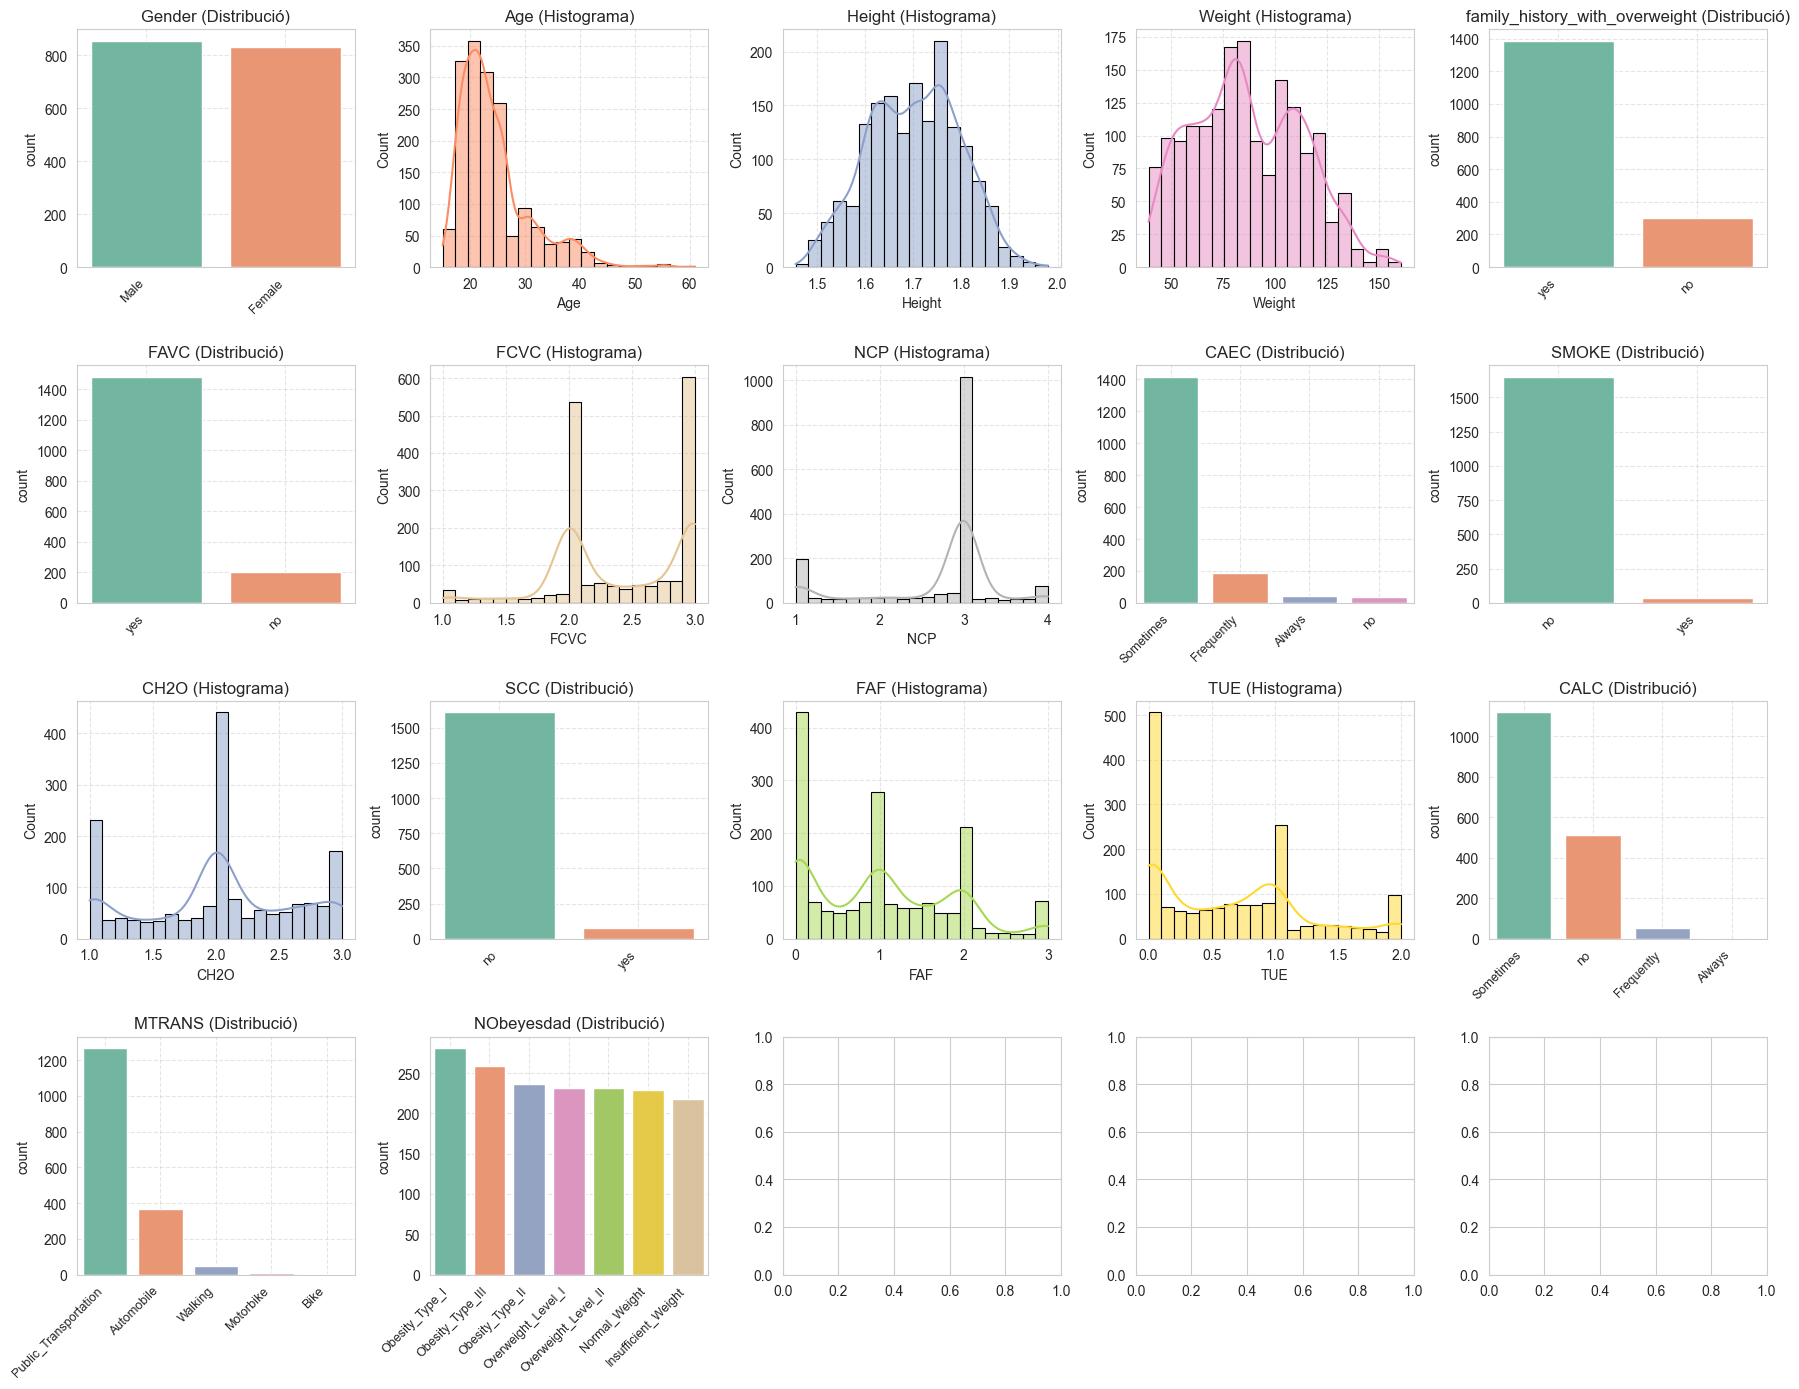

In [122]:
cols = df_tester.columns.tolist()

sns.set_style("whitegrid")
palette = sns.color_palette("Set2")

fig, axes = plt.subplots(4, 5, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cols[:17]): 
    ax = axes[i]
    
    if (not pd.api.types.is_numeric_dtype(df_tester[col])) or (df_tester[col].nunique() <= 6):
        sns.countplot(
            x=df_split[col], 
            ax=ax, 
            order=df_split[col].value_counts().index, 
            palette=palette
        )
        ax.set_title(f'{col} (Distribució)')
        ax.set_xlabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

    else:
        sns.histplot(
            data=df_split, 
            x=col, 
            bins=20, 
            kde=True, # Afegim suavització (KDE)
            color=palette[i % len(palette)], # Assigna un color de la paleta
            edgecolor='black',
            ax=ax
        )
        ax.set_title(f'{col} (Histograma)', fontsize=12)
        ax.set_xlabel(col, fontsize=10)

    
    
    ax.grid(True, linestyle='--', alpha=0.5)

for j in range(i + 1, 17):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

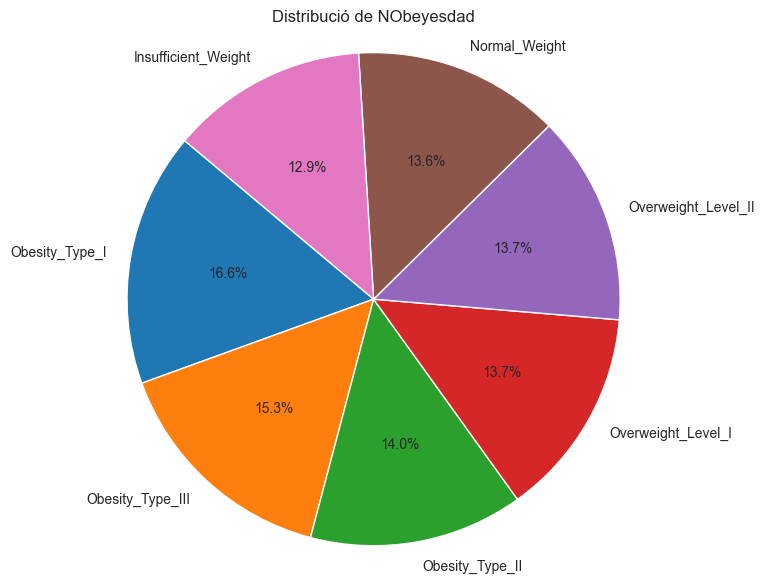

In [123]:
import matplotlib.pyplot as plt

counts = df_split['NObeyesdad'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribució de NObeyesdad')
plt.axis('equal')
plt.show()

In [124]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# Llista de variables categòriques
categorical_cols = [
    'Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 
    'SCC', 'CALC', 'MTRANS', 'CAEC', 'NObeyesdad'
]

print("### ANÀLISI PERCENTUAL DE VARIABLES CATEGÒRIQUES ###")
print("*" * 65)

# Una petita funció per formatejar percentatges
def format_percent(x):
    return f"{x:.1f} %"

# COMPACTACIÓ DE SORTIDA:
# Use display() sense salts extra ni prints innecessaris.

for col in categorical_cols:
    if col in df_split.columns:
        
        # Calcular recompte i percentatges
        count = df_split[col].value_counts().sort_index()
        percentage = df_split[col].value_counts(normalize=True).mul(100)
        
        analysis_df = pd.DataFrame({
            'Count': count,
            'Percentage (%)': percentage
        })
        
        styled_df = analysis_df.style.format({
            'Percentage (%)': format_percent,
            'Count': '{:,}'
        })

        # Títol compacte de variable
        display(HTML(f"<h4><b>VARIABLE: {col.upper()}</b></h4>"))
        
        # Mostrar taula sense línies de separació llargues
        display(HTML(styled_df._repr_html_()))

print("*" * 65)


### ANÀLISI PERCENTUAL DE VARIABLES CATEGÒRIQUES ###
*****************************************************************


,Count,Percentage (%)
Gender,,
Female,833,49.3 %
Male,855,50.7 %


,Count,Percentage (%)
family_history_with_overweight,,
no,301,17.8 %
yes,"1,387",82.2 %


,Count,Percentage (%)
FAVC,,
no,203,12.0 %
yes,"1,485",88.0 %


,Count,Percentage (%)
SMOKE,,
no,"1,651",97.8 %
yes,37,2.2 %


...

,Count,Percentage (%)
CALC,,
Always,1,0.1 %
Frequently,55,3.3 %
Sometimes,"1,118",66.2 %
no,514,30.5 %


,Count,Percentage (%)
MTRANS,,
Automobile,364,21.6 %
Bike,5,0.3 %
Motorbike,7,0.4 %
Public_Transportation,"1,267",75.1 %
Walking,45,2.7 %


,Count,Percentage (%)
CAEC,,
Always,42,2.5 %
Frequently,189,11.2 %
Sometimes,"1,418",84.0 %
no,39,2.3 %


,Count,Percentage (%)
NObeyesdad,,
Insufficient_Weight,218,12.9 %
Normal_Weight,229,13.6 %
Obesity_Type_I,281,16.6 %
Obesity_Type_II,237,14.0 %
Obesity_Type_III,259,15.3 %
Overweight_Level_I,232,13.7 %
Overweight_Level_II,232,13.7 %


*****************************************************************


La varibale resposta està balancejada, és a dir, tenim percentatges molt similars de casos per cada classe.

Podem veure que tenim variables d'entrada desbalancejades (catagòriques), per solucionar-ho agruparem les caracteristisques amb menys pes. Les variables amb un desbalanceig més gran són SMOKE i SCC.

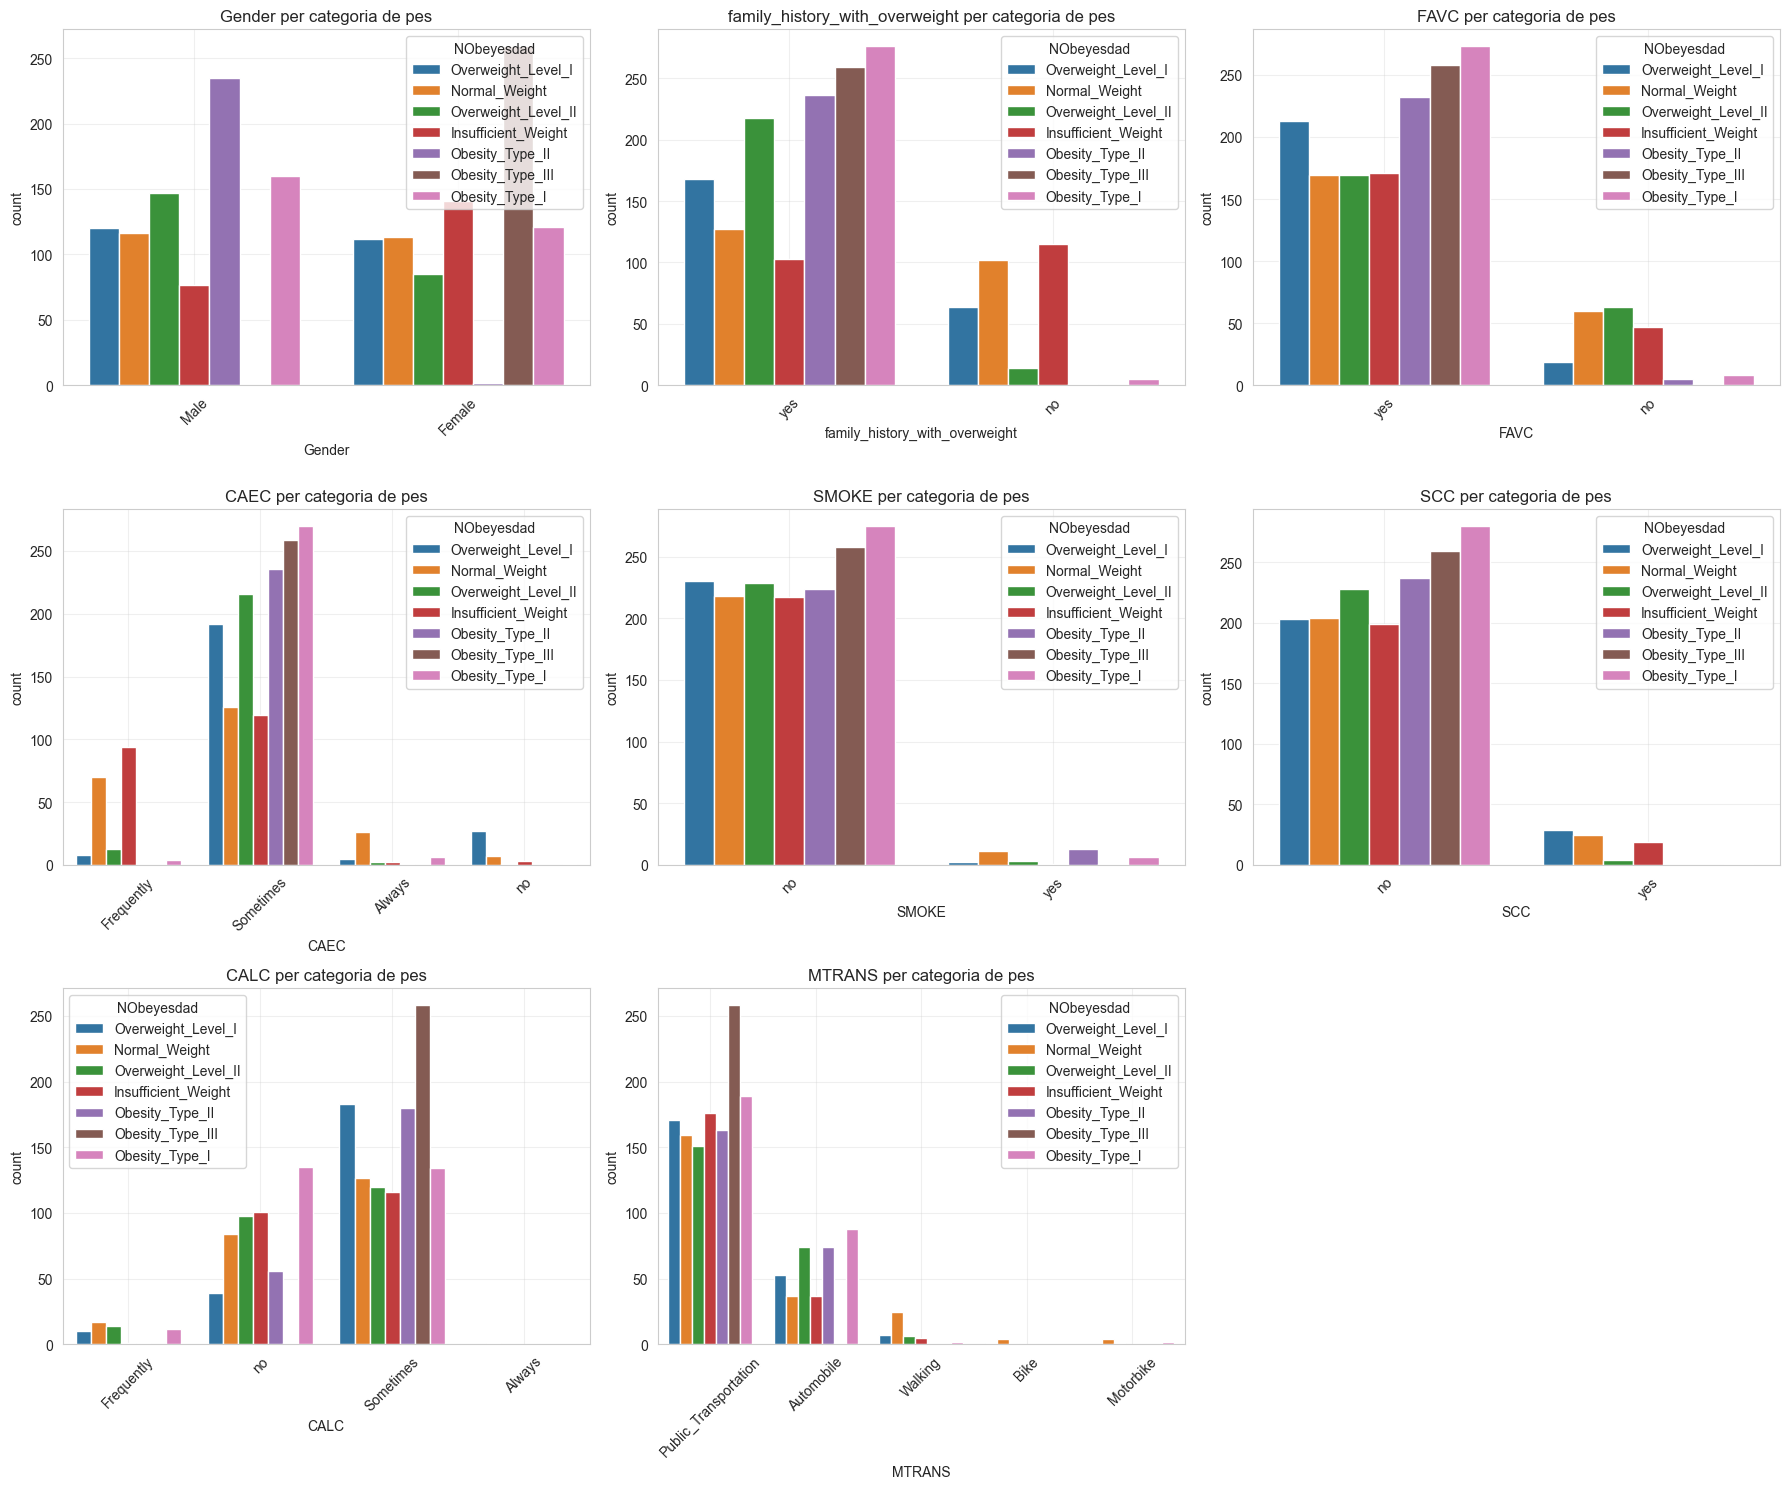

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df_split.copy()
target = "NObeyesdad"

categorical_vars = ['Gender','family_history_with_overweight','FAVC',
                    'CAEC','SMOKE','SCC','CALC','MTRANS']

# Crear graella 3x3 (perquè tens 8 variables)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(categorical_vars):
    sns.countplot(data=df, x=col, hue=target, ax=axes[i])
    axes[i].set_title(f"{col} per categoria de pes")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(alpha=0.3)

# El subplot buit (el 9è) l'amaguem
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
ax.grid(alpha=0.3)
plt.show()


- Gènere: Totes els tipus d'obesitat influeixen bastant igual en genere, menys quan tenim obesitat_tipus_III que només tenim dones, i Obesitat_tipus_II només tenim homes.
- Historial familiar: Veiem que tots els casos de persones amb obesitat(tipus I, II, III) i sobre pes nivell II només es donen quan hi ha historial familiar. 
- FAVC: Els casos amb obesitat més severa mengen altes calories més freqüentment. Quan la resposta és no veiem que predominen els casos amb menys obesitat.
- CAEC: Tenim pocs casos on responguin no o sempre, els agrupem amb a vegades i freqüentment. Podem veure que els casos que responen freqüentment o sempre són els que tenen un pes normal o insuficient. Creiem que això pot ser més una forma de perspectiva o d'acceptar la realitat, els casos amb sobrepes potser que siguin més optimitstes.
- SMOKE:  Eliminem la variable perquè els casos de fumadors i no fumadors no estan representats amb la mateixa quantitat.
- SCC: Els casos amb més obesitat no tenen un seguiment de les calories ingerides. Tot i que, no és molt fiable perquè la variable està molt desbalncejada.
- CALC: Tots els casos d'obesitat tipus_III beuen alcohol de vegades. D'entre els casos que no beuen alcohol destaca obesitat tipus I.
- MTRANS: Tenim pocs casos de Caminar, Bici i Moto, els podem agrupar. El transport públic és el mes utilitzat i en el cas de la obesitat III nomes utilitza aquest transport. Els transports que hi ha més exercici destaquen els casos amb el pes normal. Les persones amb obestitat I i II només utilitzen tranport públic o automòbil.

Visualitzem ara la distribució de les variables numèriques respecte les categories de la variable resposta.

C:\Users\annit\AppData\Local\Temp\ipykernel_26592\3767937808.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\annit\AppData\Local\Temp\ipykernel_26592\3767937808.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


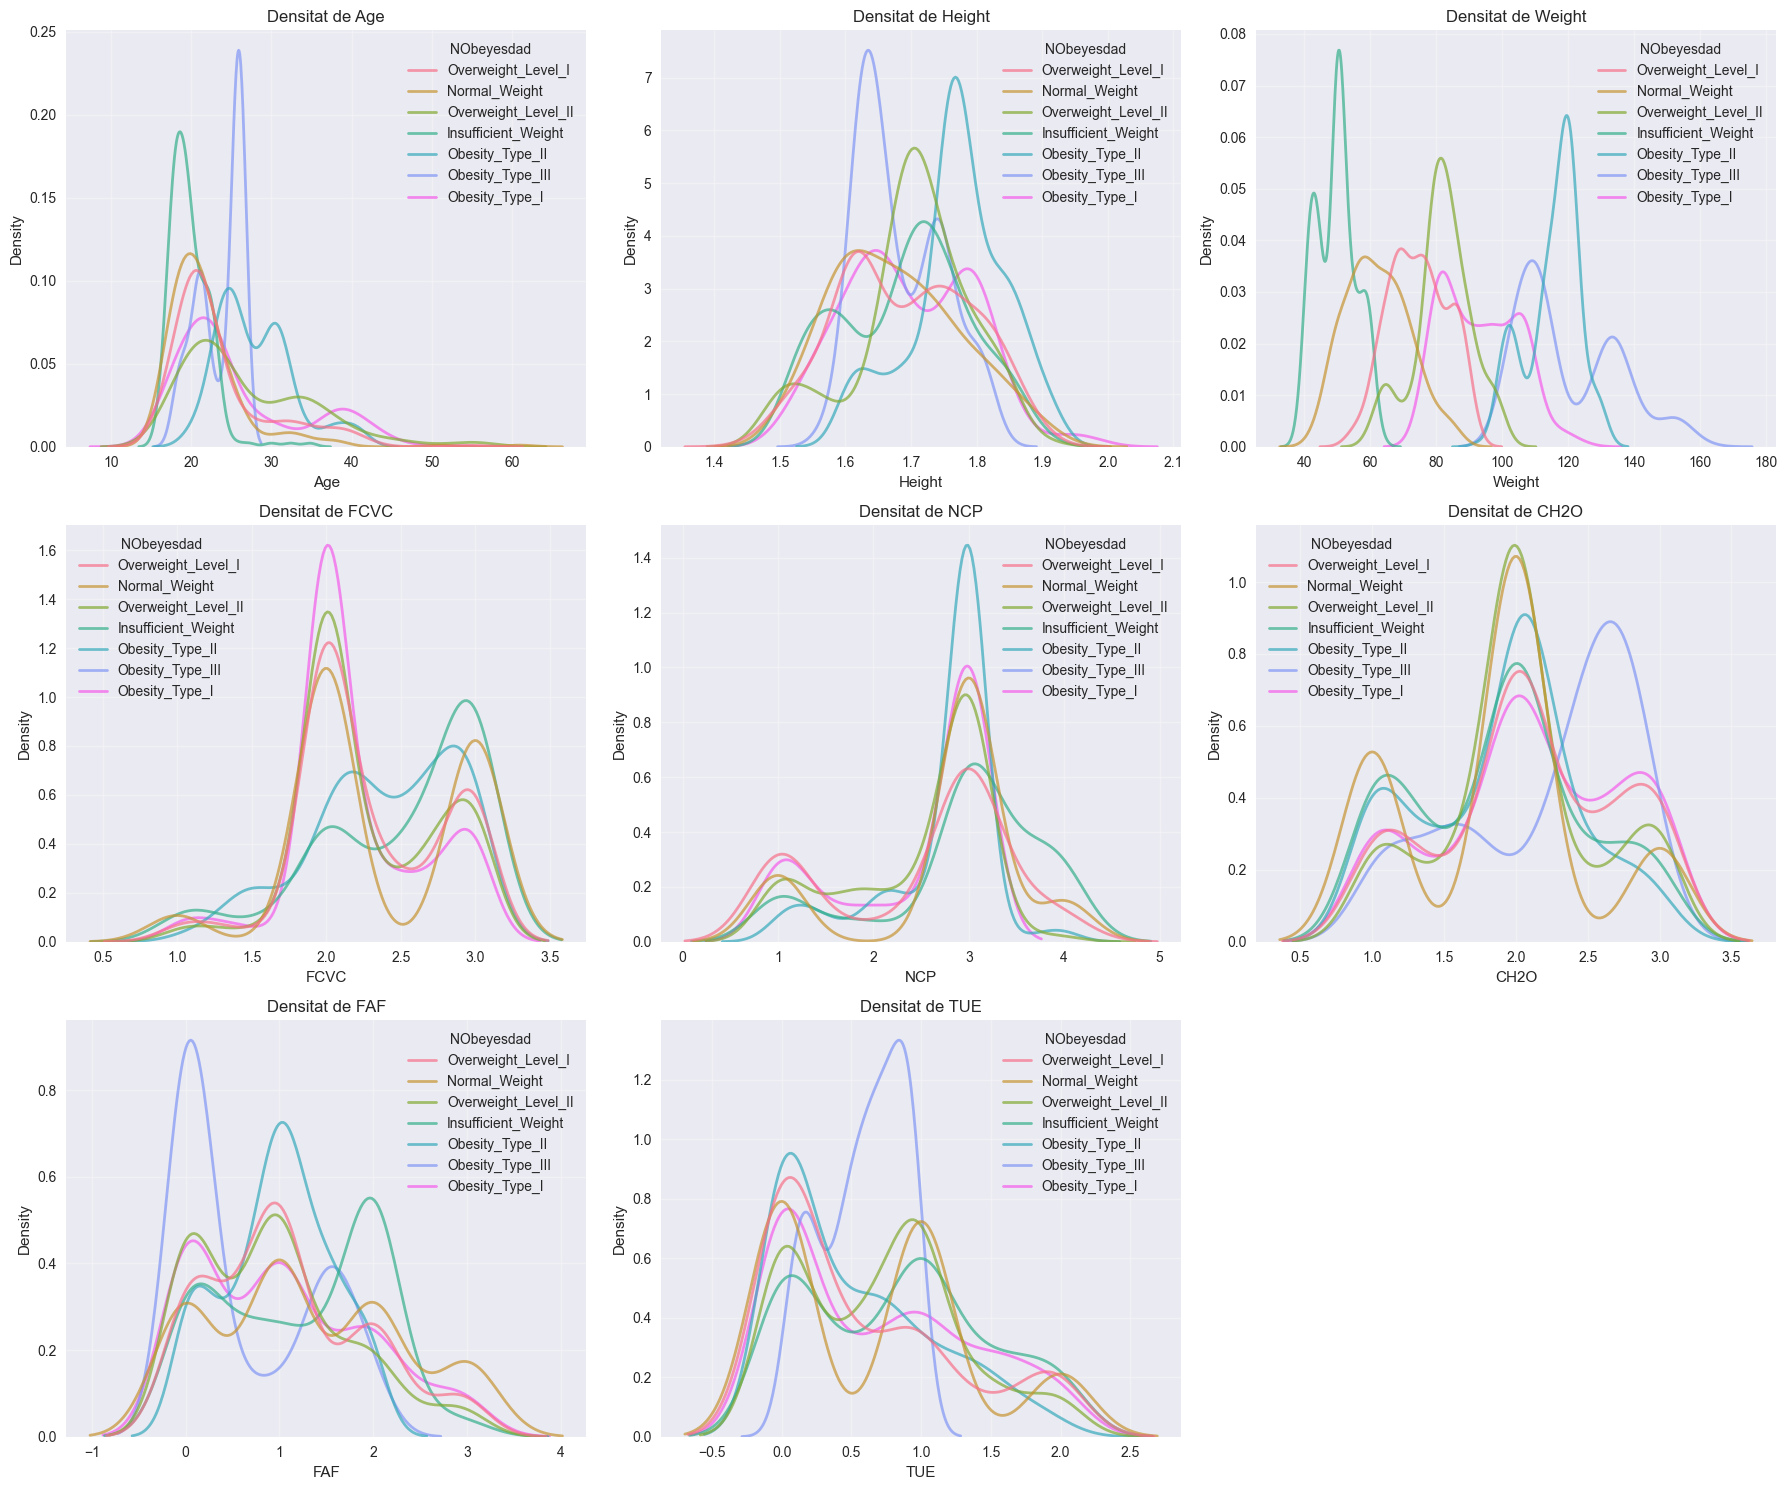

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

variables = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

plt.style.use('seaborn-v0_8')

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, var in enumerate(variables):
    ax = axes[i]
    sns.kdeplot(
        data=df_split,
        x=var,
        hue='NObeyesdad',
        common_norm=False,
        fill=False,
        alpha=0.7,
        linewidth=2,
        ax=ax
    )
    ax.set_title(f'Densitat de {var}')
    ax.grid(alpha=0.3)

# Deixar l’últim subplot buit si cal
for j in range(len(variables), 9):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

plt.style.use('default')

- AGE: La majoria de pesos es centren als voltants dels 20 anys, menys les obesitats del tipus II i III. L'obesitat_tipus_II esta repartida entre els 20 i els 35 anys i l'obesitat_tipus_III té molts casos en els 27 anys i alguns una mica abans.
-  Els casos de pes insuficient mengen amb més freqüència verdures en els seus àpats. I els casos d'obesitat_tipus_I mengen amb menys freqüència.
- FVCV (freqüència del consum de verdures): Els casos de pes insuficient mengen amb més freqüència verdures en els seus àpats. I els casos d'obesitat_tipus_I mengen amb menys freqüència.
- NCP (nombre d'àpats): Aquesta variable aportarà poca informació sobre el pes corporal, ja que la majoria de persones, independentment del seu pes, han respost que fan tres àpats al dia.
- CH20 (consum d'aigua): La major part de persones, independentment del seu pes, consumeixen al voltant d'uns 2L d'aigua al dia. Hi ha un pic de casos d'obessitat de tipus III al voltant dels 2.5-3L al dia. Igualment, a simple vista, no podem identificar cap patró clar que relacioni el consum d'aigua amb el pes.   
- FAF (freqüència d'activitat física): En aquesta variable identifiquem que la majoria de casos d'obesitat de tipus II ees donen en persones que no tenen l'hàbit de fer activitat física. Aquesta observació contrasta amb els casos d'infrapes, que predominen entre els pacients que fan més activitat física. 
- TUE (temps d'ús de dispositiu tecnològic): La majoria dels casos són bastant iguals. La majoria de casos d'obesitat de tipus III se centren a 1, mentres que la resta estan repartits entre 0 i 1. Així que inicialment no podem extreure-hi cap comportament especific d'aquesta variable. 

## Preprocessament

Mirem de agrupar algunes categories de variables que tenen menys pes.
I mirem si hi ha outliers a les númeriques.

In [127]:
df_split.loc[df_split["MTRANS"].isin(['Bike', 'Motorbike', 'Walking']), "MTRANS"] = 'ALTRES'
df_split.loc[df_split["CAEC"].isin(['Frequently',"Always"]), "CAEC"] = 'Freq o always'
df_split.loc[df_split["CALC"].isin(['Frequently',"Always"]), "CALC"] = 'Freq o always'
df_split.loc[df_split["CAEC"].isin(['Sometimes',"no"]), "CAEC"] = 'Sometimes o no'
# Borrem smoke perque esta molt descompensat
df_split= df_split.drop(columns="SMOKE")

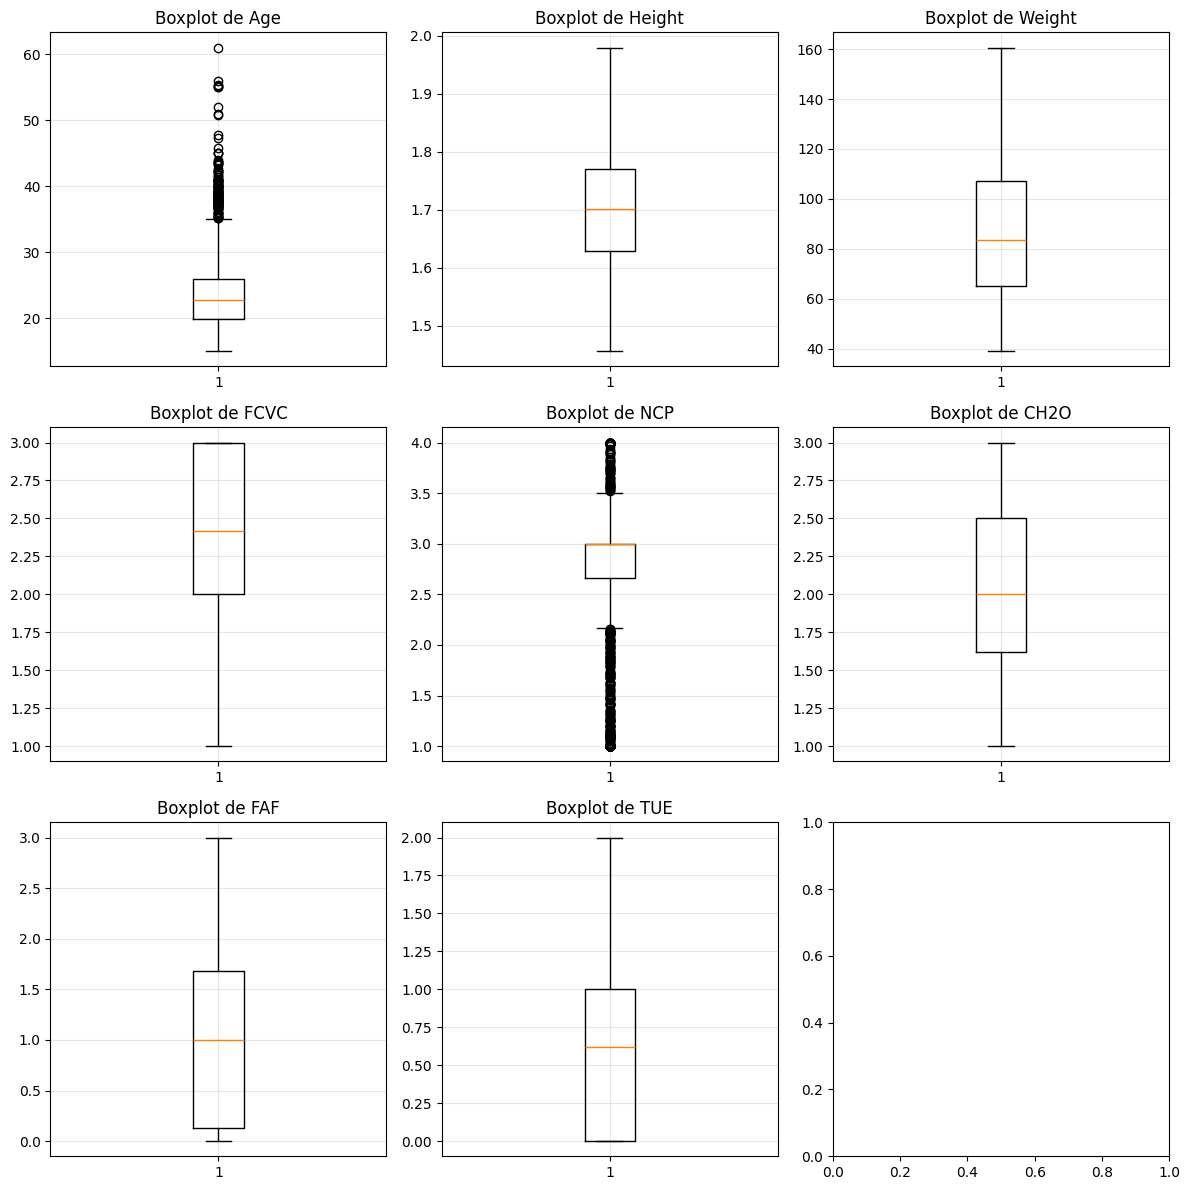

In [128]:
# Seleccionem només les variables numèriques
numeriques = df_split.select_dtypes(include=['float64', 'int64']).columns

# Definim la quadrícula 3x2
fig, axes = plt.subplots(3, 3, figsize=(12, 12))  # 3 files, 2 columnes
axes = axes.flatten()  # convertim a array 1D per iterar més fàcil

# Fem el boxplot per cada variable
for i, col in enumerate(numeriques[:8]):  # Només 6 variables per a 3x2
    axes[i].boxplot(df_split[col])
    axes[i].grid(alpha=0.3)
    axes[i].set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

Tot i que en els boxplots d'AGE i NCP apareixen alguns valors marcat com a outliers, aquests no els considerem outliers reals. En el cas d'AGE, els valors més elevats corresponen simplement a pacients de més edat. Matemàticament es marquen com a outliers ja que la majoria de persones són joves/adolescents, però les edats de les persones més grans són igual de reals. Pel que fa a NCP, el nombre d'àpats al dia pot variar naturalment entre 1 i 4, segons els hàbits de cada persona, aquests resultats són realistes. Per tant, no arreglem cap outlier perquè no representen errors ni valors anormals.

### Passem a numèriques les variables categòriques

In [129]:
df_split = pd.get_dummies(df_split, columns=['MTRANS'])
df_split.head()

bool_cols = df_split.select_dtypes(include='bool').columns
df_split[bool_cols] = df_split[bool_cols].astype('Int64')

In [130]:
df_split.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,CH2O,SCC,FAF,TUE,CALC,NObeyesdad,MTRANS_ALTRES,MTRANS_Automobile,MTRANS_Public_Transportation
459,Male,19.000000,1.760000,79.000000,yes,yes,2.000000,3.000000,Freq o always,3.000000,no,1.000000,2.000000,Freq o always,Overweight_Level_I,0,0,1
426,Male,22.000000,1.750000,70.000000,no,no,2.000000,3.000000,Sometimes o no,3.000000,no,1.000000,1.000000,no,Normal_Weight,0,0,1
326,Male,18.000000,1.700000,55.300000,yes,yes,3.000000,3.000000,Sometimes o no,2.000000,no,3.000000,0.000000,Sometimes,Normal_Weight,0,0,1
971,Male,19.506389,1.824449,87.656029,yes,yes,2.793561,3.788602,Sometimes o no,2.429059,no,2.094542,0.393358,Sometimes,Overweight_Level_I,0,0,1
892,Female,17.085250,1.535618,57.259124,no,yes,1.972545,2.339614,Sometimes o no,1.711074,yes,0.095517,1.191053,Sometimes,Overweight_Level_I,0,0,1


In [131]:
df_split['Gender'] = df_split['Gender'].replace({'Male': 1, 'Female': 0})
df_split['family_history_with_overweight'] = df_split['family_history_with_overweight'].replace({'yes': 1, 'no': 0})
df_split['FAVC'] = df_split['FAVC'].replace({'yes': 1, 'no': 0})
df_split['SCC'] = df_split['SCC'].replace({'yes': 1, 'no': 0})
df_split['CALC'] = df_split['CALC'].replace({'Freq o always': 2,'Sometimes':1 , 'no': 0})
df_split['CAEC'] = df_split['CAEC'].replace({'Freq o always': 1,'Sometimes o no': 0})

C:\Users\annit\AppData\Local\Temp\ipykernel_26592\2369482247.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_split['Gender'] = df_split['Gender'].replace({'Male': 1, 'Female': 0})
C:\Users\annit\AppData\Local\Temp\ipykernel_26592\2369482247.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_split['family_history_with_overweight'] = df_split['family_history_with_overweight'].replace({'yes': 1, 'no': 0})
C:\Users\annit\AppData\Local\Temp\ipykernel_26592\2369482247.py:3: FutureWarning: Downcasting behavior in `replace` is 

In [132]:
df_split.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,CH2O,SCC,FAF,TUE,CALC,NObeyesdad,MTRANS_ALTRES,MTRANS_Automobile,MTRANS_Public_Transportation
459,1,19.000000,1.760000,79.000000,1,1,2.000000,3.000000,1,3.000000,0,1.000000,2.000000,2,Overweight_Level_I,0,0,1
426,1,22.000000,1.750000,70.000000,0,0,2.000000,3.000000,0,3.000000,0,1.000000,1.000000,0,Normal_Weight,0,0,1
326,1,18.000000,1.700000,55.300000,1,1,3.000000,3.000000,0,2.000000,0,3.000000,0.000000,1,Normal_Weight,0,0,1
971,1,19.506389,1.824449,87.656029,1,1,2.793561,3.788602,0,2.429059,0,2.094542,0.393358,1,Overweight_Level_I,0,0,1
892,0,17.085250,1.535618,57.259124,0,1,1.972545,2.339614,0,1.711074,1,0.095517,1.191053,1,Overweight_Level_I,0,0,1


### Variable resposta

La classificació de NObeyesdad s'assigna de la següent manera segons el valor de BMI (body mass index):
- Underweight Less than 18.5
- Normal 18.5 to 24.9
- Overweight 25.0 to 29.9
- Obesity I 30.0 to 34.9
- Obesity II 35.0 to 39.9
- Obesity III Higher than 40

Per calcular el BMI: $ BMI = \frac{weight}{height^2}$. Veiem que tant el pes com l'alçada tindran una gran influència a l'hora de classificar. Com el que volem és estudiar el pes que tenen la resta de variables no tant obvies, cosiderarem una nova base de dades que no tingui en compte la variable Height ni la variable Weight.

In [133]:
# Borrem les variables pes i alçada
df_clean = df_split.copy().drop(columns=['Weight', 'Height'])

In [134]:
df_clean['NObeyesdad'] = df_clean['NObeyesdad'].replace({'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Overweight_Level_I': 2, 'Overweight_Level_II': 3, 'Obesity_Type_I': 4, 'Obesity_Type_II': 5, 'Obesity_Type_III': 6})

C:\Users\annit\AppData\Local\Temp\ipykernel_26592\3205114863.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['NObeyesdad'] = df_clean['NObeyesdad'].replace({'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Overweight_Level_I': 2, 'Overweight_Level_II': 3, 'Obesity_Type_I': 4, 'Obesity_Type_II': 5, 'Obesity_Type_III': 6})


In [135]:
df_clean['NObeyesdad'].value_counts()

NObeyesdad
4    281
6    259
5    237
2    232
3    232
1    229
0    218
Name: count, dtype: int64

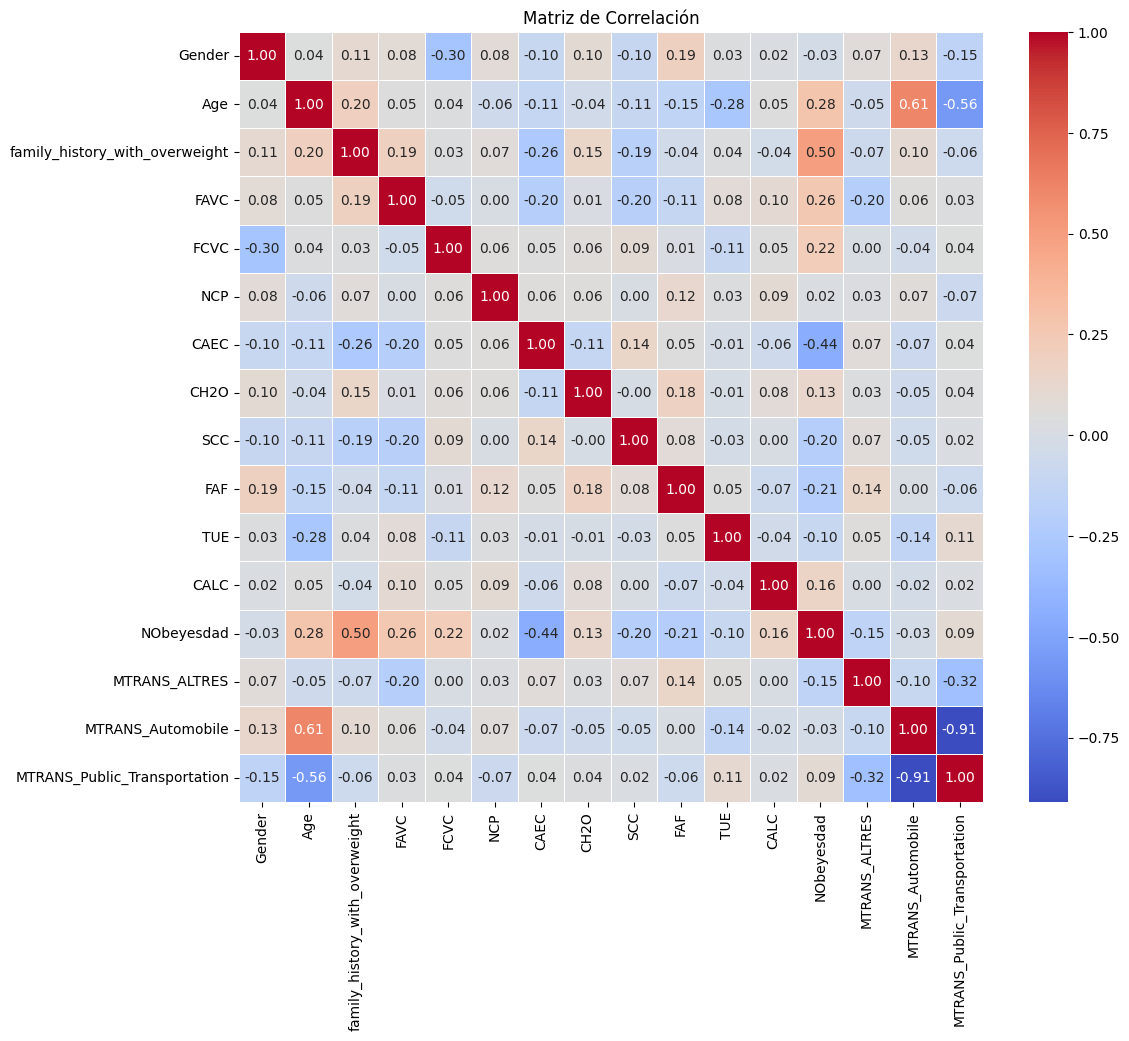

In [136]:
corr_matrix = df_clean.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación')
plt.show()

(Cor)Relacions amb la variable NObeyesdad:
- L'historia de la familia té bastanta relació 
- La variable SCC I CALC tenen poc pes.
- La variable transport(automobil) també té poc pes però està relacionada amb les altres de transport

Variables que estan correlaciones:
- Transport públic amb l'edat (invers)
- Automobil amb l'edat
- Transport públic amb l'automobil (invers)


Mirem un histograma general de la distribuició de totes les variables per veure si hem de fer normalització

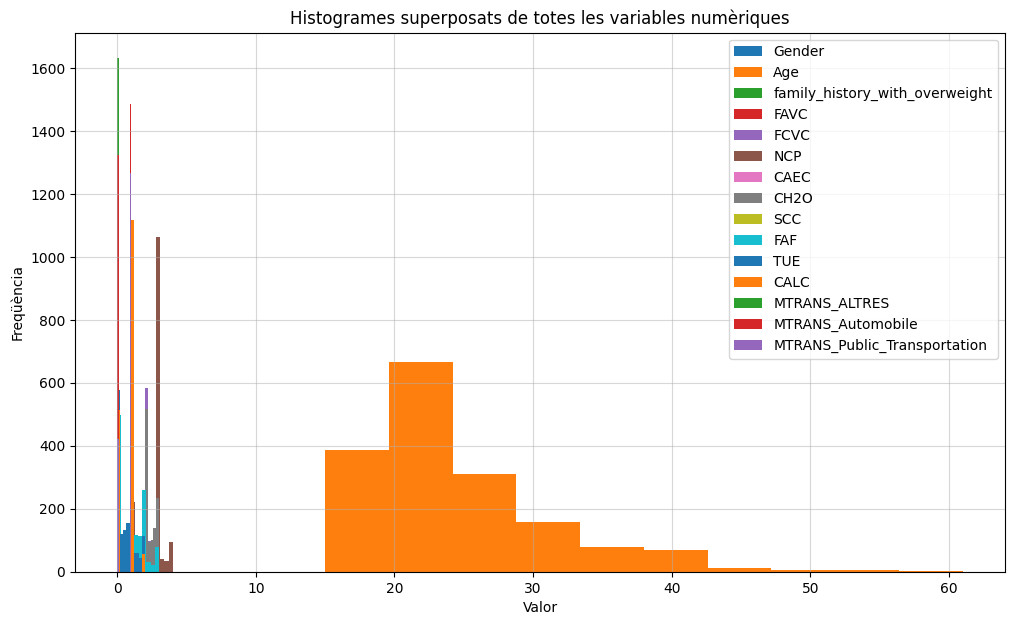

In [137]:
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = [col for col in numeric_cols if col != 'NObeyesdad']

# Fem l'histograma superposat
plt.figure(figsize=(12, 7))

for col in numeric_cols:
    plt.hist(df_clean[col], bins=10, alpha=1, label=col)

plt.title("Histogrames superposats de totes les variables numèriques")
plt.xlabel("Valor")
plt.ylabel("Freqüència")
axes[i].grid(alpha=0.5)
plt.grid(alpha=0.5)
plt.legend(loc='upper right', fontsize=10)
plt.show()

La normalització la fem amb z-score. Estem fent normalització a tota la base de dades, s'hauria de fer NOMÉS al training (desrpés del split)

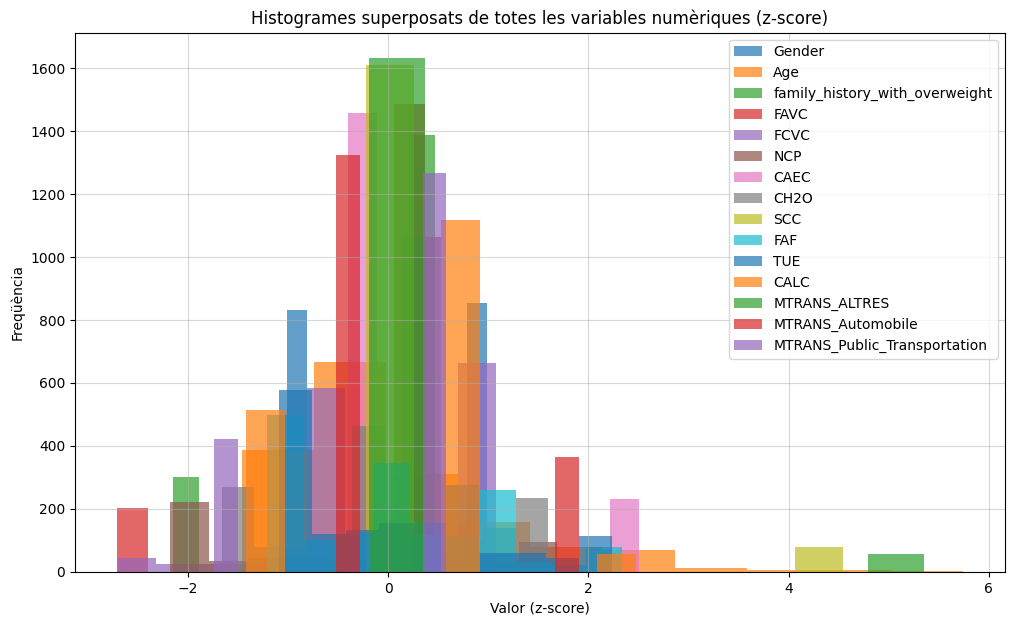

In [138]:
# Seleccionem només les columnes numèriques
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = [col for col in numeric_cols if col != 'NObeyesdad']

# Transformem a z-score
train_means = {}
train_stds = {}

for col in numeric_cols:
    train_means[col] = df_clean[col].mean()
    train_stds[col] = df_clean[col].std()
    df_clean[col] = (df_clean[col] - train_means[col]) / train_stds[col]

# Fem l'histograma superposat
plt.figure(figsize=(12, 7))

for col in numeric_cols:
    plt.hist(df_clean[col], bins=10, alpha=0.7, label=col)  # alpha=0.5 per veure superposició

plt.title("Histogrames superposats de totes les variables numèriques (z-score)")
plt.xlabel("Valor (z-score)")
plt.ylabel("Freqüència")
plt.legend(loc='upper right', fontsize=10)
plt.grid(alpha=0.5)
plt.show()


Un cop tenim les dades normalitzades mirem si cal eliminar alguna variable. Provarem diferents mètodes:
- Lasso
- Ridge
- Feature selection de random forest

In [139]:
X = df_clean[[c for c in df_clean.columns if c != 'NObeyesdad']]
y = df_clean['NObeyesdad']

### Lasso

In [140]:
model_lasso = Lasso(alpha=0.05)
model_lasso.fit(X, y)

coef = pd.Series(model_lasso.coef_, index=X.columns)
print("\nCoeficients del model LASSO:")
display(coef.sort_values(key=abs, ascending=False).to_frame("Pes de la variable"))


Coeficients del model LASSO:


,Pes de la variable
family_history_with_overweight,0.663272
CAEC,-0.570986
Age,0.461601
MTRANS_Public_Transportation,0.387233
FCVC,0.358680
FAF,-0.196035
CALC,0.170865
FAVC,0.151851
SCC,-0.094000
TUE,-0.058592


In [141]:
### Ridge

In [142]:
model_ridge = Ridge()
model_ridge.fit(X,y)

coef = pd.Series(model_ridge.coef_, index=X.columns)
print("\nCoeficients del model Ridge:")
display(coef.sort_values(key=abs, ascending=False).to_frame("Pes de la variable"))


Coeficients del model Ridge:


,Pes de la variable
family_history_with_overweight,0.673846
CAEC,-0.603169
Age,0.561318
FCVC,0.389037
MTRANS_Public_Transportation,0.275010
MTRANS_Automobile,-0.270985
FAF,-0.231816
CALC,0.193192
FAVC,0.188297
SCC,-0.128176


### Feature selection - Random Forest

In [143]:
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
display(importances.sort_values(ascending=False).to_frame("Pes de la variable"))

,Pes de la variable
family_history_with_overweight,0.246587
Age,0.127926
CAEC,0.126842
FCVC,0.125330
FAF,0.069884
NCP,0.067610
TUE,0.055472
MTRANS_Public_Transportation,0.050983
Gender,0.045126
CALC,0.026616


Les variables que ha predit el random forest té en compte també relacions no lineals. Però per ara no utilitzem regularitzaions perquè tenim una base de dades amb moltíssimes variables i és menys probable pugui haver overfiiting. Si més endevant tenim overfitting, aplicarem alguna d'aquestes regularitzacions.

Per tant, de moment considerem el model amb totes les variables (menys SMOKE, Alçada i Pes).

In [144]:
X_red = df_clean[[c for c in df_clean.columns if c != 'NObeyesdad']]
y_red = df_clean['NObeyesdad']

## Metric selection
Hem de triar una mètrica per comparar models:
- R²: compara la variància total de la variable dependent amb la variància que el model no ha pogut explicar, si el model te poca variancia, surt un r2 baix i potser molt bo i fa creure que el model no generalitza, tot i que sí ho fa.
- MAE: Serveix per mesurar com d’equivocat està un model, de mitjana, sense exagerar els errors grans.si la MAE és baixa el model és millor.
- RMSE: mesura com s’equivoca el model però penalitzant més fortament els errors grans (eleva els errors al quadrat).
És útil si volem posar més pes als casos on la predicció falla molt. Si n'hi un de molt gran la metrica li dona molt de pes. 

De moment utilitzem RMSE, penalitza els errors més grans

## Model selection

Algoritmes que utilitzarem:
- Regressió lineal.
- Random Forest
- Gradient boosting (XGBoost,LightGBM)
- SVR

## Validació creuada
Fem validació creuada amb els hiperparàmetres per defecte, per tenir una primera impressió. 

hauriem de mirar quants k folds fem, no cal separar les dades perq el cros validation ja ho fa en cada iteracio

In [145]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

models = {
        "LinearRegression": LinearRegression(),
        "RandomForest": RandomForestRegressor(),
        "XGBoost": XGBRegressor(),
        "LightGBM": LGBMRegressor(),
        "SVR": SVR()
}
cv_scores = {'LinearRegression': [], 'RandomForest': [], 'XGBoost': [], 'LightGBM': [], 'SVR': []}
cv_scores_mean = {'LinearRegression': [], 'RandomForest': [], 'XGBoost': [], 'LightGBM': [], 'SVR': []}
test_scores = {'LinearRegression': [], 'RandomForest': [], 'XGBoost': [], 'LightGBM': [], 'SVR': []}
total_times = {'LinearRegression': [], 'RandomForest': [], 'XGBoost': [], 'LightGBM': [], 'SVR': []}

cv = KFold(n_splits=5,shuffle=True) 
rmse_scorer = make_scorer(rmse)

for name, model in models.items():
    start_time = time.time()
    cv_rmse_values = cross_val_score(model, X_red, y_red, cv=cv, scoring=rmse_scorer)
    end_time = time.time()
    
    cv_scores[name].extend(cv_rmse_values)            # per al boxplot
    cv_scores_mean[name].append(cv_rmse_values.mean())  # per a la taula
    total_times[name].append(end_time - start_time)


# Crear taula resum amb mitjanes
results = pd.DataFrame({
    'Model': ['LinearRegression', 'RandomForest', 'XGBoost', 'LightGBM', 'SVR'],
    'Validació RMSE (mitjana)': [
        np.mean(cv_scores_mean['LinearRegression']),
        np.mean(cv_scores_mean['RandomForest']),
        np.mean(cv_scores_mean['XGBoost']),
        np.mean(cv_scores_mean['LightGBM']),
        np.mean(cv_scores_mean['SVR'])
    ],
    'Temps total (s)': [  # canviat el nom
        np.mean(total_times['LinearRegression']),
        np.mean(total_times['RandomForest']),
        np.mean(total_times['XGBoost']),
        np.mean(total_times['LightGBM']),
        np.mean(total_times['SVR'])
    ]
})

# Mostrar taula formatejada
styled = (
    results.style
    .set_caption("Comparació de models amb RMSE i temps total (validació creuada 5-fold)")
    .format({
        'Validació rmse (mitjana)': '{:.3f}',
        'Temps total (s)': '{:.4f}'
    })
)

styled

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000548 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1557
[LightGBM] [Info] Number of data points in the train set: 1350, number of used features: 15
[LightGBM] [Info] Start training from score 3.070370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000453 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1431
[LightGBM] [Info] Number of data points in the train set: 1350, number of used features: 15
[LightGBM] [Info] Start training from score 3.100000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000327 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1431
[LightGBM] [Info] Number of data points in the train set: 1350, number of used features: 15
[LightGBM] [Info] Start traini

,Model,Validació RMSE (mitjana),Temps total (s)
0,LinearRegression,1.367592,0.0260
1,RandomForest,0.724834,2.5218
2,XGBoost,0.756395,0.8118
3,LightGBM,0.726180,0.8116
4,SVR,0.835560,0.5263


C:\Users\annit\AppData\Local\Temp\ipykernel_26592\1065180267.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([cv_scores[m] for m in models.keys()], labels=models.keys())


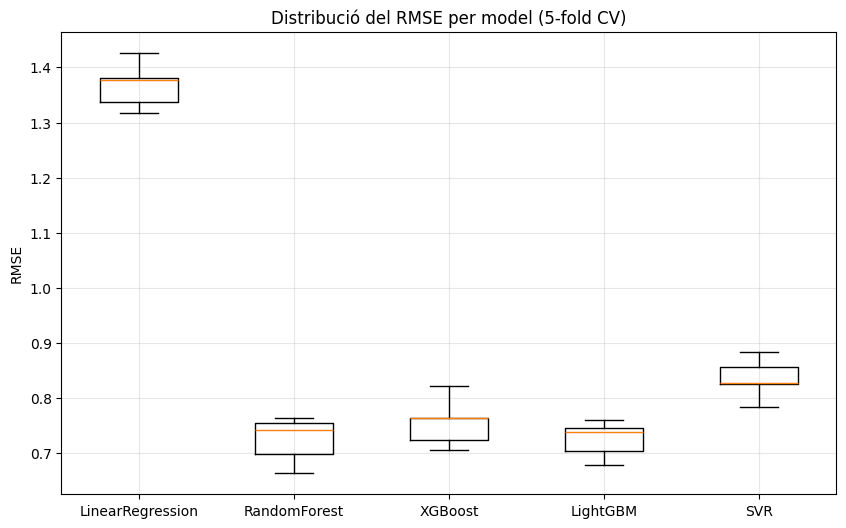

In [146]:
plt.figure(figsize=(10,6))
plt.boxplot([cv_scores[m] for m in models.keys()], labels=models.keys())
plt.ylabel("RMSE")
plt.title("Distribució del RMSE per model (5-fold CV)")
plt.grid( alpha=0.3)
plt.show()


Volem un valor RMSE baix. De moment amb els hiperparàmetres per defecte, obtenim millors resultats amb el RandomForest, XGBoost i LightGBM. Així que farem la cerca d'hiperparametres dels models més prometedors per tal d'estalviar temps de computació.

## Cerca d'hiperparàmetres

### RandomForest

In [147]:
param = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

cv = KFold(n_splits = 5)
rmse_scorer = make_scorer(rmse,greater_is_better=False)


grid_search = GridSearchCV(RandomForestRegressor(), param, scoring = rmse_scorer, cv = cv,n_jobs=-1)
grid_search.fit(X_red, y_red)

print("Millors hiperparàmetres trobats RandomForest:")
print(grid_search.best_params_)
print(f"RMSE (mitjà CV): {-grid_search.best_score_:.4f}")



Millors hiperparàmetres trobats RandomForest:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
RMSE (mitjà CV): 0.7388


### XGBoost

In [148]:
# Hiperparàmetres 
param_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01 , 0.1, 0.2],
    'subsample': [0.7, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scorer = make_scorer(rmse, greater_is_better=False)  # important: per GridSearchCV, RMSE ha de ser negatiu

# GridSearchCV
grid_search_xgb = GridSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid=param_xgb,
    scoring=rmse_scorer,
    cv=cv,
    n_jobs=-1
)

# Entrenar i buscar millors hiperparàmetres
grid_search_xgb.fit(X_red, y_red)

# Resultats
print("Millors hiperparàmetres trobats XGBoost:")
print(grid_search_xgb.best_params_)
print(f"RMSE Validació (mitjana): {-grid_search_xgb.best_score_:.4f}")


Millors hiperparàmetres trobats XGBoost:
{'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100, 'subsample': 0.7}
RMSE Validació (mitjana): 0.7015


### LightGBM

In [149]:
# Hiperparàmetres 
param_lgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],   
    'learning_rate': [0.01, 0.1, 0.2],
    'num_leaves': [31, 50, 100]
}

# KFold per CV
cv = KFold(n_splits=5, shuffle=True)
rmse_scorer = make_scorer(rmse, greater_is_better=False)  # RMSE: valors més petits són millors

# GridSearchCV
grid_search_lgb = GridSearchCV(
    LGBMRegressor(random_state=42),
    param_grid=param_lgb,
    scoring=rmse_scorer,
    cv=cv,
    n_jobs=-1, # va amb paral·lel, mes rapid
)

# Entrenar i buscar millors hiperparàmetres
grid_search_lgb.fit(X_red, y_red)

# Resultats
print("Millors hiperparàmetres trobats LightGBM:")
print(grid_search_lgb.best_params_)
print(f"RMSE Validació (mitjana): {-grid_search_lgb.best_score_:.4f}")



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000972 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1557
[LightGBM] [Info] Number of data points in the train set: 1688, number of used features: 15
[LightGBM] [Info] Start training from score 3.111374
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [150]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

models_best = {
    "RandomForest": grid_search.best_estimator_,
    "XGBoost": grid_search_xgb.best_estimator_,
    "LightGBM": grid_search_lgb.best_estimator_,
}

# --- 3. Cross-validation amb els millors models ---
cv_scores = {name: [] for name in models_best}
cv_scores_mean = {name: [] for name in models_best}
total_times = {name: [] for name in models_best}

for name, model in models_best.items():
    start_time = time.time()
    cv_rmse_values = cross_val_score(model, X_red, y_red, cv=cv, scoring=rmse_scorer)
    end_time = time.time()
    
    cv_scores[name].extend(-cv_rmse_values)
    cv_scores_mean[name].append((-cv_rmse_values).mean())
    total_times[name].append(end_time - start_time)

# --- 4. Crear taula resum amb mitjanes ---
results = pd.DataFrame({
    'Model': list(models_best.keys()),
    'Validació RMSE (mitjana)': [np.mean(cv_scores_mean[name]) for name in models_best],
    'Temps total (s)': [np.mean(total_times[name]) for name in models_best]
})

# --- 5. Mostrar taula formatejada ---
styled = (
    results.style
    .set_caption("Comparació de models amb RMSE i temps total (validació creuada 5-fold)")
    .format({
        'Train CV RMSE (mitjana)': '{:.3f}',
        'Temps total (s)': '{:.4f}'
    })
)

styled

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000511 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1557
[LightGBM] [Info] Number of data points in the train set: 1350, number of used features: 15
[LightGBM] [Info] Start training from score 3.096296
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,Model,Validació RMSE (mitjana),Temps total (s)
0,RandomForest,0.721719,6.0157
1,XGBoost,0.715926,2.2428
2,LightGBM,0.758544,8.9719


### Boxplot de comparacio de models amb validació creuada i els hiperparametres triats

C:\Users\annit\AppData\Local\Temp\ipykernel_26592\2080536243.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([cv_scores[m] for m in models_best.keys()], labels=models_best.keys())


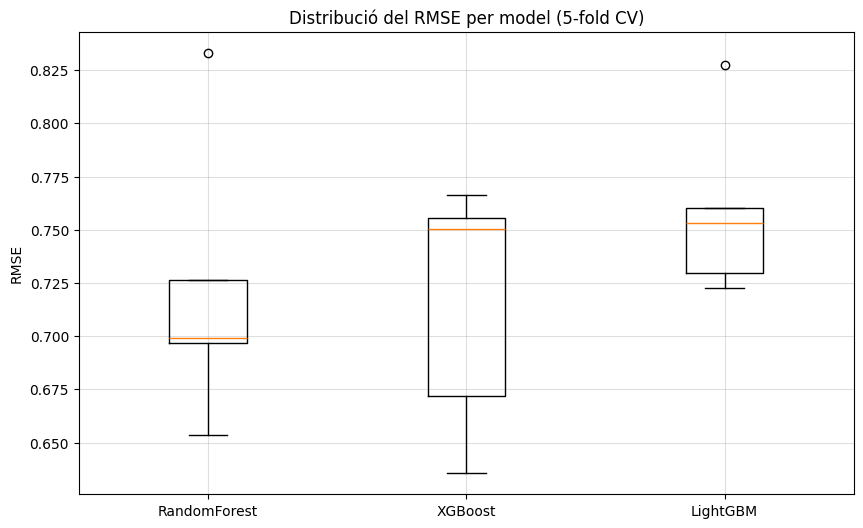

In [151]:
plt.figure(figsize=(10,6))
plt.boxplot([cv_scores[m] for m in models_best.keys()], labels=models_best.keys())
plt.ylabel("RMSE")
plt.title("Distribució del RMSE per model (5-fold CV)")
plt.grid( alpha=0.4)
plt.show()


El millor model és el *XGBoost* amb els hiperparàmetres: learning_rate: 0.1, max_depth: 10, n_estimators: 100, subsample: 0.7

## Anàlisi final

Preparem el dataset que ens servirà per fer el test

In [152]:
nan_counts=df_tester.isna().sum()
var_type = df_tester.dtypes

print("Valors NaN per atribut i tipus de variable:")
print(pd.DataFrame({"NaN Count": nan_counts, "Variable Type": var_type}))

Valors NaN per atribut i tipus de variable:
                                NaN Count Variable Type
Gender                                  0        object
Age                                     0       float64
Height                                  0       float64
Weight                                  0       float64
family_history_with_overweight          0        object
FAVC                                    0        object
FCVC                                    0       float64
NCP                                     0       float64
CAEC                                    0        object
SMOKE                                   0        object
CH2O                                    0       float64
SCC                                     0        object
FAF                                     0       float64
TUE                                     0       float64
CALC                                    0        object
MTRANS                                  0        object
NObe

No hi ha valors NaN.
Tenim les mateixes variables que amb training, per tant fem one-hot encoding per la variable MTRANS, i convertim en numèriques les variables categòriques Gender, amily_history_with_overweight, FAVC, SMOKE, SCC, CALC, CAEC

In [153]:
# Fem One-Hot-Encoding per la variable MTRANS
df_tester.loc[df_tester["MTRANS"].isin(['Bike', 'Motorbike', 'Walking']), "MTRANS"] = 'ALTRES'
df_tester = pd.get_dummies(df_tester, columns=['MTRANS'])
bool_cols = df_tester.select_dtypes(include='bool').columns
df_tester[bool_cols] = df_tester[bool_cols].astype(int)
df_tester.loc[df_tester["CAEC"].isin(['Frequently',"Always"]), "CAEC"] = 'Freq o always'
df_tester.loc[df_tester["CALC"].isin(['Frequently',"Always"]), "CALC"] = 'Freq o always'
df_tester.loc[df_tester["CAEC"].isin(['Sometimes',"no"]), "CAEC"] = 'Sometimes o no'

# Convertim en numèriques les variables categòriques
df_tester['Gender'] = df_tester['Gender'].replace({'Male': 1, 'Female': 0})
df_tester['family_history_with_overweight'] = df_tester['family_history_with_overweight'].replace({'yes': 1, 'no': 0})
df_tester['FAVC'] = df_tester['FAVC'].replace({'yes': 1, 'no': 0})
df_tester['SCC'] = df_tester['SCC'].replace({'yes': 1, 'no': 0})
df_tester['CALC'] = df_tester['CALC'].replace({'Freq o always': 2,'Sometimes':1 , 'no': 0})
df_tester['CAEC'] = df_tester['CAEC'].replace({'Freq o always': 1,'Sometimes o no': 0})

# Regressió de la variable resposta segons l'encondig utilitzat abans (train)
df_tester['NObeyesdad_encoded'] = df_tester['NObeyesdad'].replace({'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Overweight_Level_I': 5, 'Overweight_Level_II': 6, 'Obesity_Type_I': 2, 'Obesity_Type_II': 3, 'Obesity_Type_III': 4})

# treiem la variable pes i alçada
df_tester = df_tester.drop(columns=['Weight', 'Height'])

#borrem smoke perque esta molt descompensat
df_tester = df_tester.drop(columns=["SMOKE"])

#borrem nobeyesdad
df_tester = df_tester.drop(columns=['NObeyesdad'])

C:\Users\annit\AppData\Local\Temp\ipykernel_26592\1100161142.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_tester['Gender'] = df_tester['Gender'].replace({'Male': 1, 'Female': 0})
C:\Users\annit\AppData\Local\Temp\ipykernel_26592\1100161142.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_tester['family_history_with_overweight'] = df_tester['family_history_with_overweight'].replace({'yes': 1, 'no': 0})
C:\Users\annit\AppData\Local\Temp\ipykernel_26592\1100161142.py:13: FutureWarning: Downcasting behavior in `repla

In [154]:
#Normalitzem les variables d'entrada utilitzant les mitjanes i desviacions estàndard del train
numeric_cols = df_tester.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = [col for col in numeric_cols if col != 'NObeyesdad_encoded']
for col in numeric_cols:
        df_tester[col] = (df_tester[col] - train_means[col]) / train_stds[col]

Entrenem el model final

In [155]:
df_tester

,Gender,Age,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,CH2O,SCC,FAF,TUE,CALC,MTRANS_ALTRES,MTRANS_Automobile,MTRANS_Public_Transportation,NObeyesdad_encoded
572,-1.012819,-0.817386,-2.145983,0.369621,1.079882,1.338340,-0.398059,-1.347918,-0.220042,1.155586,0.576283,0.527854,-0.186888,-0.524177,0.576267,0
370,0.986758,-0.830677,-2.145983,0.369621,-0.809345,0.402234,-0.398059,-1.660045,-0.220042,-0.024250,0.576283,-1.417598,-0.186888,-0.524177,0.576267,1
1002,0.986758,-0.031522,0.465711,0.369621,-0.809345,0.402234,-0.398059,1.404787,-0.220042,-1.204086,-0.551963,0.527854,-0.186888,-0.524177,0.576267,6
1837,-1.012819,-0.526899,0.465711,0.369621,1.079882,0.402234,-0.398059,1.016811,-0.220042,-0.635930,0.135373,0.527854,-0.186888,-0.524177,0.576267,4
1724,0.986758,1.405200,0.465711,0.369621,0.474694,-0.351604,-0.398059,-1.660045,-0.220042,1.140597,-1.088792,-1.417598,-0.186888,-0.524177,0.576267,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1548,0.986758,0.988391,0.465711,0.369621,1.012473,0.402234,-0.398059,0.585915,-0.220042,-0.478536,2.033262,0.527854,-0.186888,1.906622,-1.734277,3
1161,0.986758,-0.958665,0.465711,-2.703874,0.121587,-0.539083,-0.398059,-0.041387,-0.220042,0.509587,0.350804,-1.417598,-0.186888,-0.524177,0.576267,6
1537,0.986758,1.026258,0.465711,0.369621,0.905589,1.680293,-0.398059,-1.660045,-0.220042,1.155291,-1.088792,-1.417598,-0.186888,-0.524177,0.576267,3
497,0.986758,-0.674247,-2.145983,-2.703874,-0.809345,0.402234,-0.398059,-0.029296,-0.220042,-0.024250,0.576283,0.527854,-0.186888,-0.524177,0.576267,1


In [156]:
final_model = XGBRegressor(learning_rate = 0.1, max_depth = 10, n_estimators = 200)

final_model.fit(X_red, y_red)

X_test = df_tester[[col for col in df_tester if col != 'NObeyesdad_encoded']]
y_test = df_tester['NObeyesdad_encoded']

y_pred = final_model.predict(X_test)

print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")


RMSE: 2.0629486983073875


El model final ens dona un RMSE de 1,62 per poder comparar amb el model de classificació transformarem els valors predits en nombres enters (0 al 6) i utilitzarem una metrica de classificació (Accuracy).

## Canvi a classificació

In [157]:
y_pred_class = np.floor(y_pred + 0.5).astype(int)
y_pred_class = np.clip(y_pred_class, 0, 6)

In [158]:
accuracy_score(y_test, y_pred_class)

0.1938534278959811

In [159]:
y_test

572     0
370     1
1002    6
1837    4
1724    3
       ..
1548    3
1161    6
1537    3
497     1
1396    2
Name: NObeyesdad_encoded, Length: 423, dtype: int64

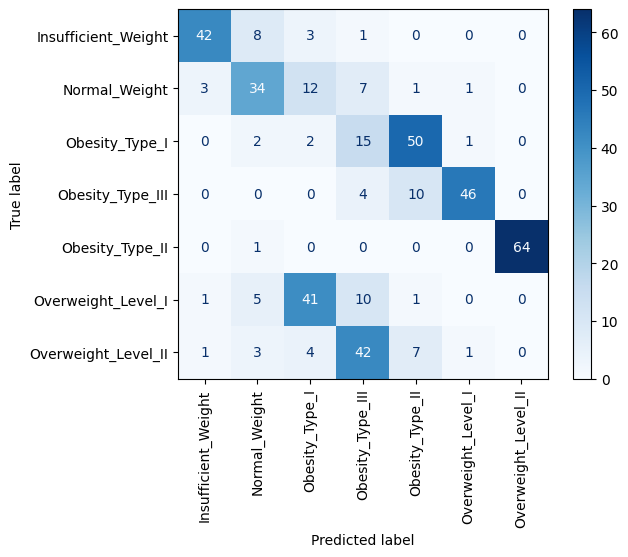

              precision    recall  f1-score   support

           0       0.89      0.78      0.83        54
           1       0.64      0.59      0.61        58
           2       0.03      0.03      0.03        70
           3       0.05      0.07      0.06        60
           4       0.00      0.00      0.00        65
           5       0.00      0.00      0.00        58
           6       0.00      0.00      0.00        58

    accuracy                           0.19       423
   macro avg       0.23      0.21      0.22       423
weighted avg       0.21      0.19      0.20       423



<Figure size 1200x1200 with 0 Axes>

In [160]:
# Fem la matriu de confussió
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_class) # S'ha de canviar el model al que trobem més òptim
etiquetes_personalitzades = [
    'Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 
    'Obesity_Type_III', 'Obesity_Type_II', 'Overweight_Level_I', 
    'Overweight_Level_II'
]
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=etiquetes_personalitzades)
disp.plot(cmap=plt.cm.Blues,  xticks_rotation='vertical')
plt.show()
plt.figure(figsize=(12, 12))

# Metriques
print (classification_report(y_test, y_pred_class))